

---

## Topic 1: Introduction to RNNs – Why We Need Them

### 1. Introduction
**What it is:**  
A **Recurrent Neural Network (RNN)** is a special type of neural network designed to work with **sequential data** – data where order matters (like sentences, movie reviews, time series, audio, etc.).

**Why important:**  
Regular neural networks (like CNNs or standard feedforward networks) **cannot handle sequential data well** for two main reasons:
1. **Variable length** – sequences can be of different lengths (e.g., movie reviews have different numbers of words). Fixed-size inputs don't work well.
2. **Hidden information** – in a sequence, the meaning of a word often depends on previous words. Regular networks process all inputs independently, so they lose the "memory" of what came before.

**Real-life use:**  
- Sentiment analysis (positive/negative movie reviews)  
- Language translation  
- Speech recognition  
- Time series forecasting (stock prices, weather)

---

### 2. Detailed Explanation

#### The Problem with Sequential Data
Imagine you are reading the English sentence:  
> "This movie actor is good"

You read it **sequentially** – word by word. By the time you reach "good", you have kept "This", "movie", "actor", and "is" in your mind. Only then can you understand the full meaning.

A regular neural network would process each word **independently** – it has no memory of previous words. This is a major limitation.

#### Why RNNs are Different
RNNs have a **memory feature** – they can remember information from previous inputs in the sequence. This is achieved through **feedback connections**: the hidden layer sends information back to itself, creating a loop.

**Two Major Differences from Feedforward Networks:**
1. **Inputs are fed one at a time** (not all at once) – word by word, time step by time step.
2. **Information flows backward too** – the hidden layer has a feedback loop, so output from one step is used as input for the next step.

#### Data Format for RNN
Your data is represented as:  
**(Time Steps, Input Features)**

**Example – Sentiment Analysis:**
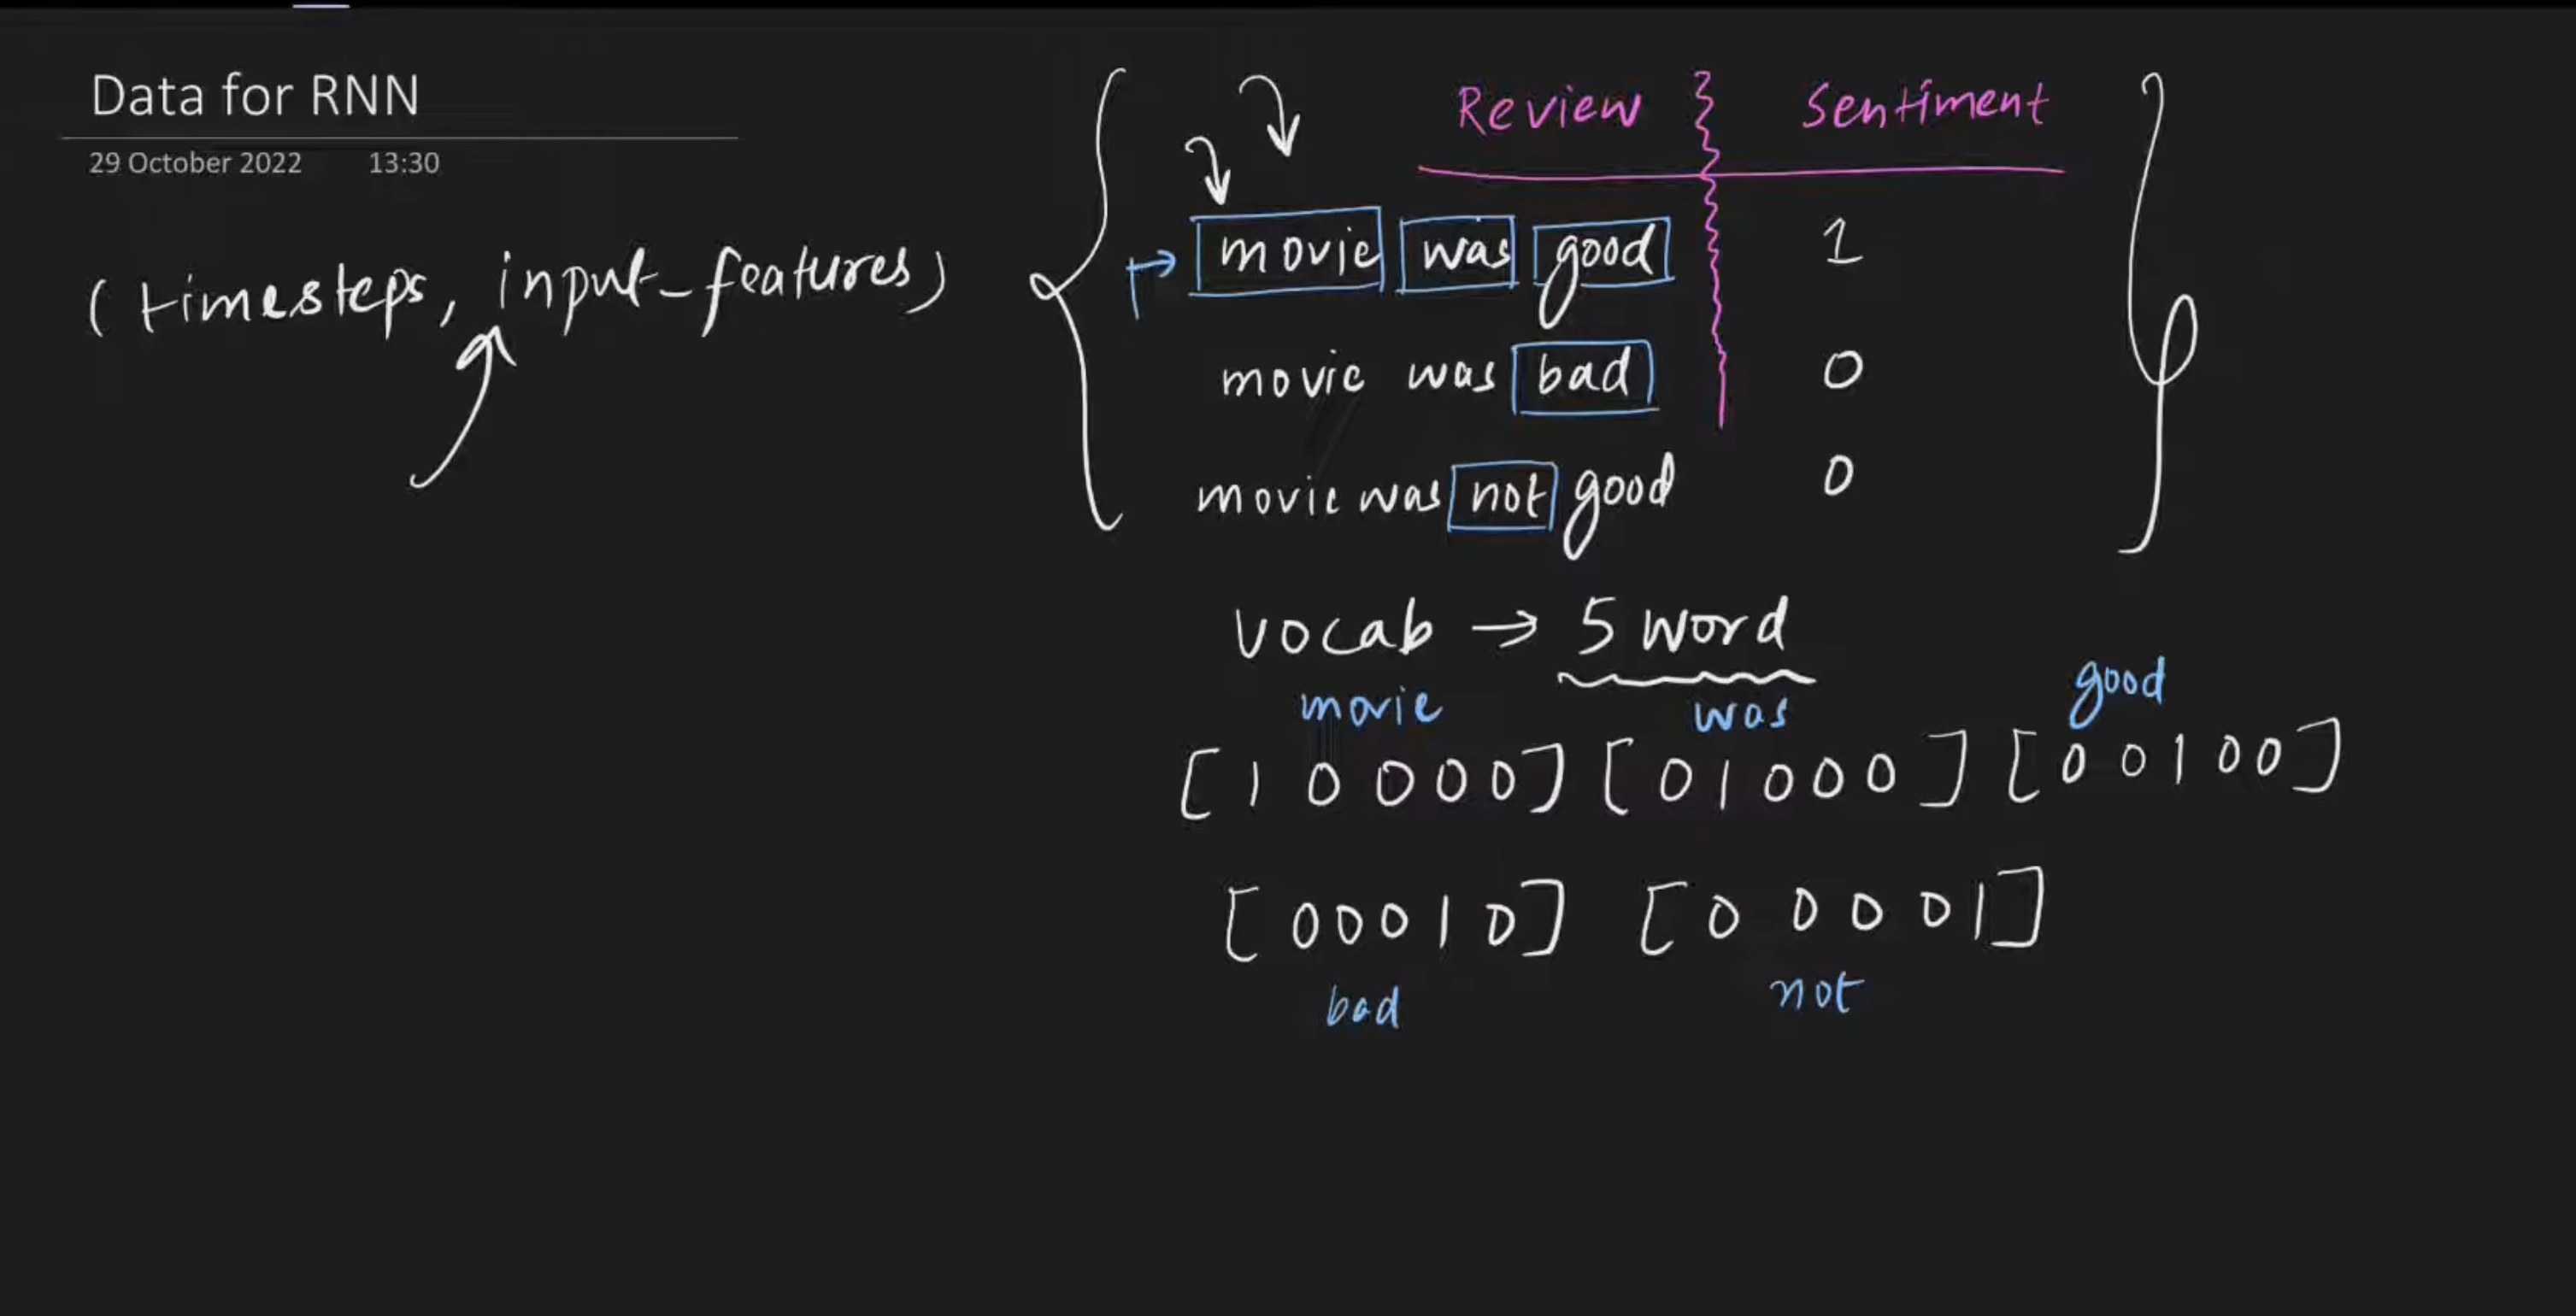
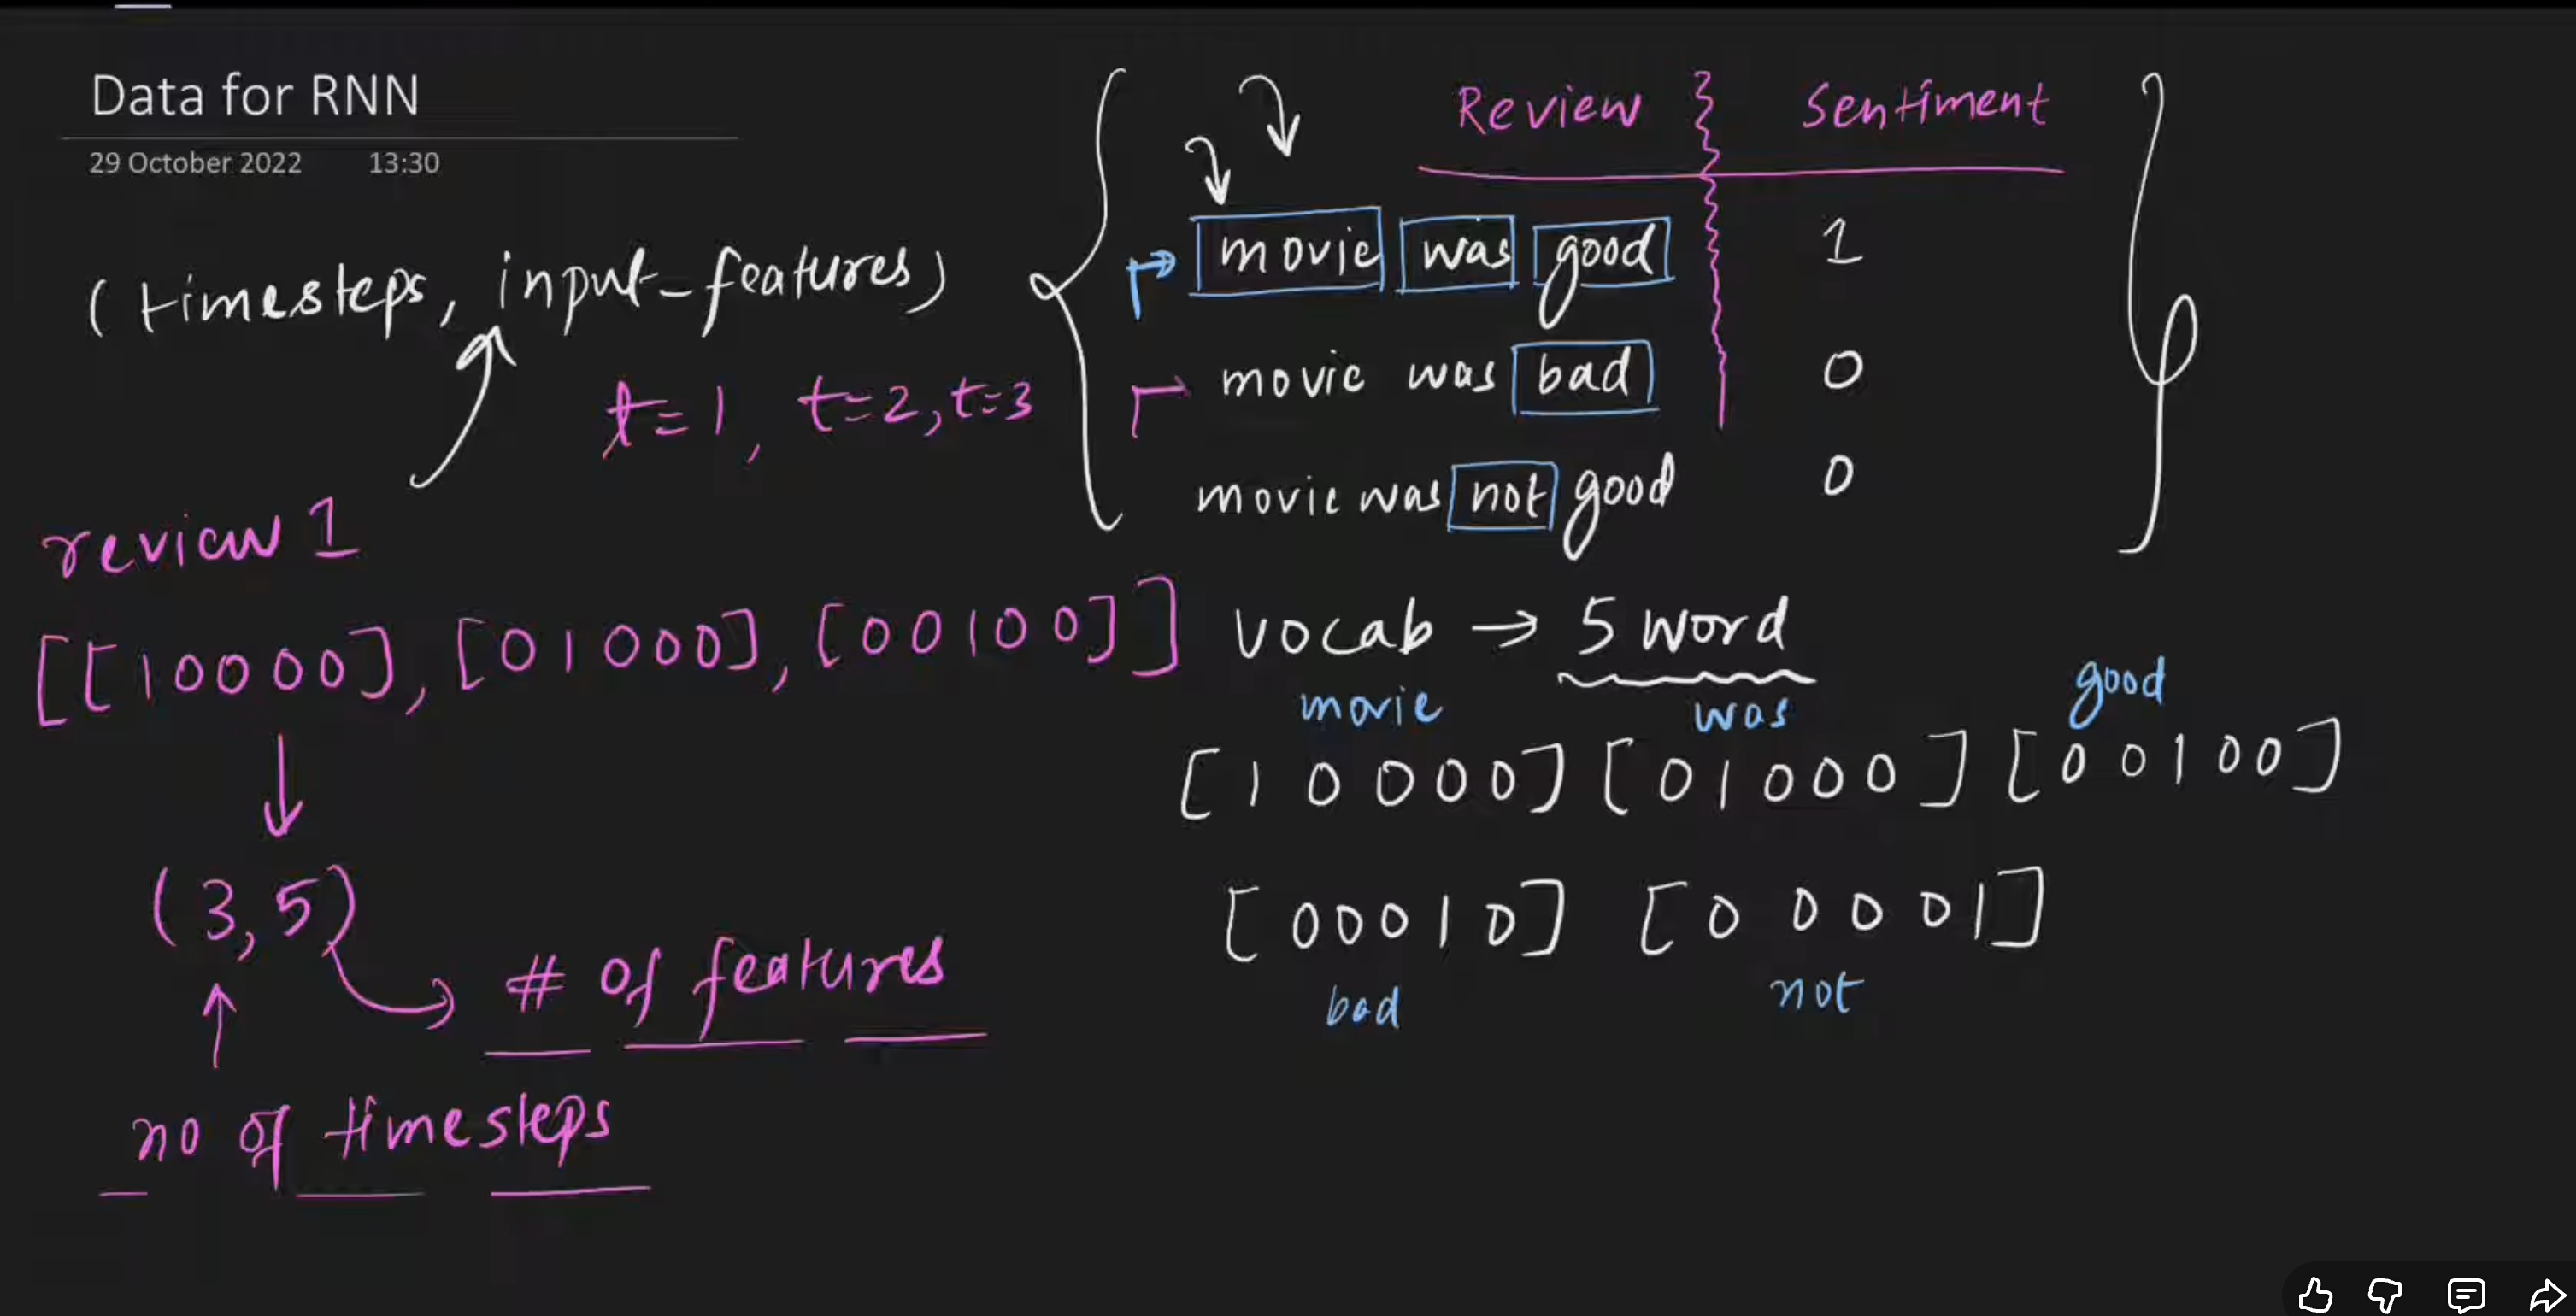

- Vocabulary: `[this, movie, actor, is, good]` → 5 words
- Each word is represented as a **vector of 5 numbers** (one-hot encoding)
- A review like "this movie actor" has **3 time steps** (3 words) and **5 input features** (vocabulary size)

| Time Step | Word | Vector Representation |
|-----------|------|------------------------|
| t=1       | this | [1,0,0,0,0]            |
| t=2       | movie| [0,1,0,0,0]            |
| t=3       | actor| [0,0,1,0,0]            |

So input shape = (3 time steps, 5 features)

---

### 3. Key Points

- RNNs are designed for **sequential data** where order matters.
- They solve two key problems: **variable sequence length** and **hidden context/information**.
- RNNs have **memory** – they pass information from one time step to the next.
- Inputs are fed **one time step at a time**.
- The hidden layer has a **feedback loop** – output from the previous step becomes input for the current step.
- RNNs use **weight sharing** – the same weights are used across all time steps.

---

### 4. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Thinking RNNs process all inputs at once | RNNs process sequentially, time step by time step | Remember: inputs are fed one word at a time |
| Confusing RNNs with feedforward networks | RNNs have feedback loops; feedforward only moves forward | Look for the recurrent connection in the architecture |
| Forgetting that the previous output is used as input | This is the core of RNN memory | Always include the previous hidden state in your forward propagation calculation |
| Assuming all sequences must be same length | RNNs can handle variable lengths | Pad shorter sequences or use dynamic unrolling |

---

### 5. Revision Notes

- RNN = neural network with **memory** for sequential data.
- Regular networks fail because: (a) variable length, (b) no memory of past inputs.
- Data format = **(time steps, input features)**.
- Key innovation: **feedback loop** in hidden layer.
- Output from time `t-1` becomes additional input at time `t`.

---

**That concludes Topic 1.**  


## Topic 2: RNN Architecture – Structure and Components

### 1. Introduction
**What it is:**  
The **architecture of an RNN** describes how the network is structured – the input layer, hidden layer(s), output layer, and most importantly, the **recurrent connections** that loop information back into the network.

**Why important:**  
Understanding the architecture helps you visualize how data flows through the network, how memory works, and how predictions are made. It is the foundation for understanding forward propagation and backpropagation.

**Real-life use:**  
Whenever you build an RNN for any sequential task (sentiment analysis, translation, speech), you are designing or using this same architecture with minor variations.

---

### 2. Detailed Explanation
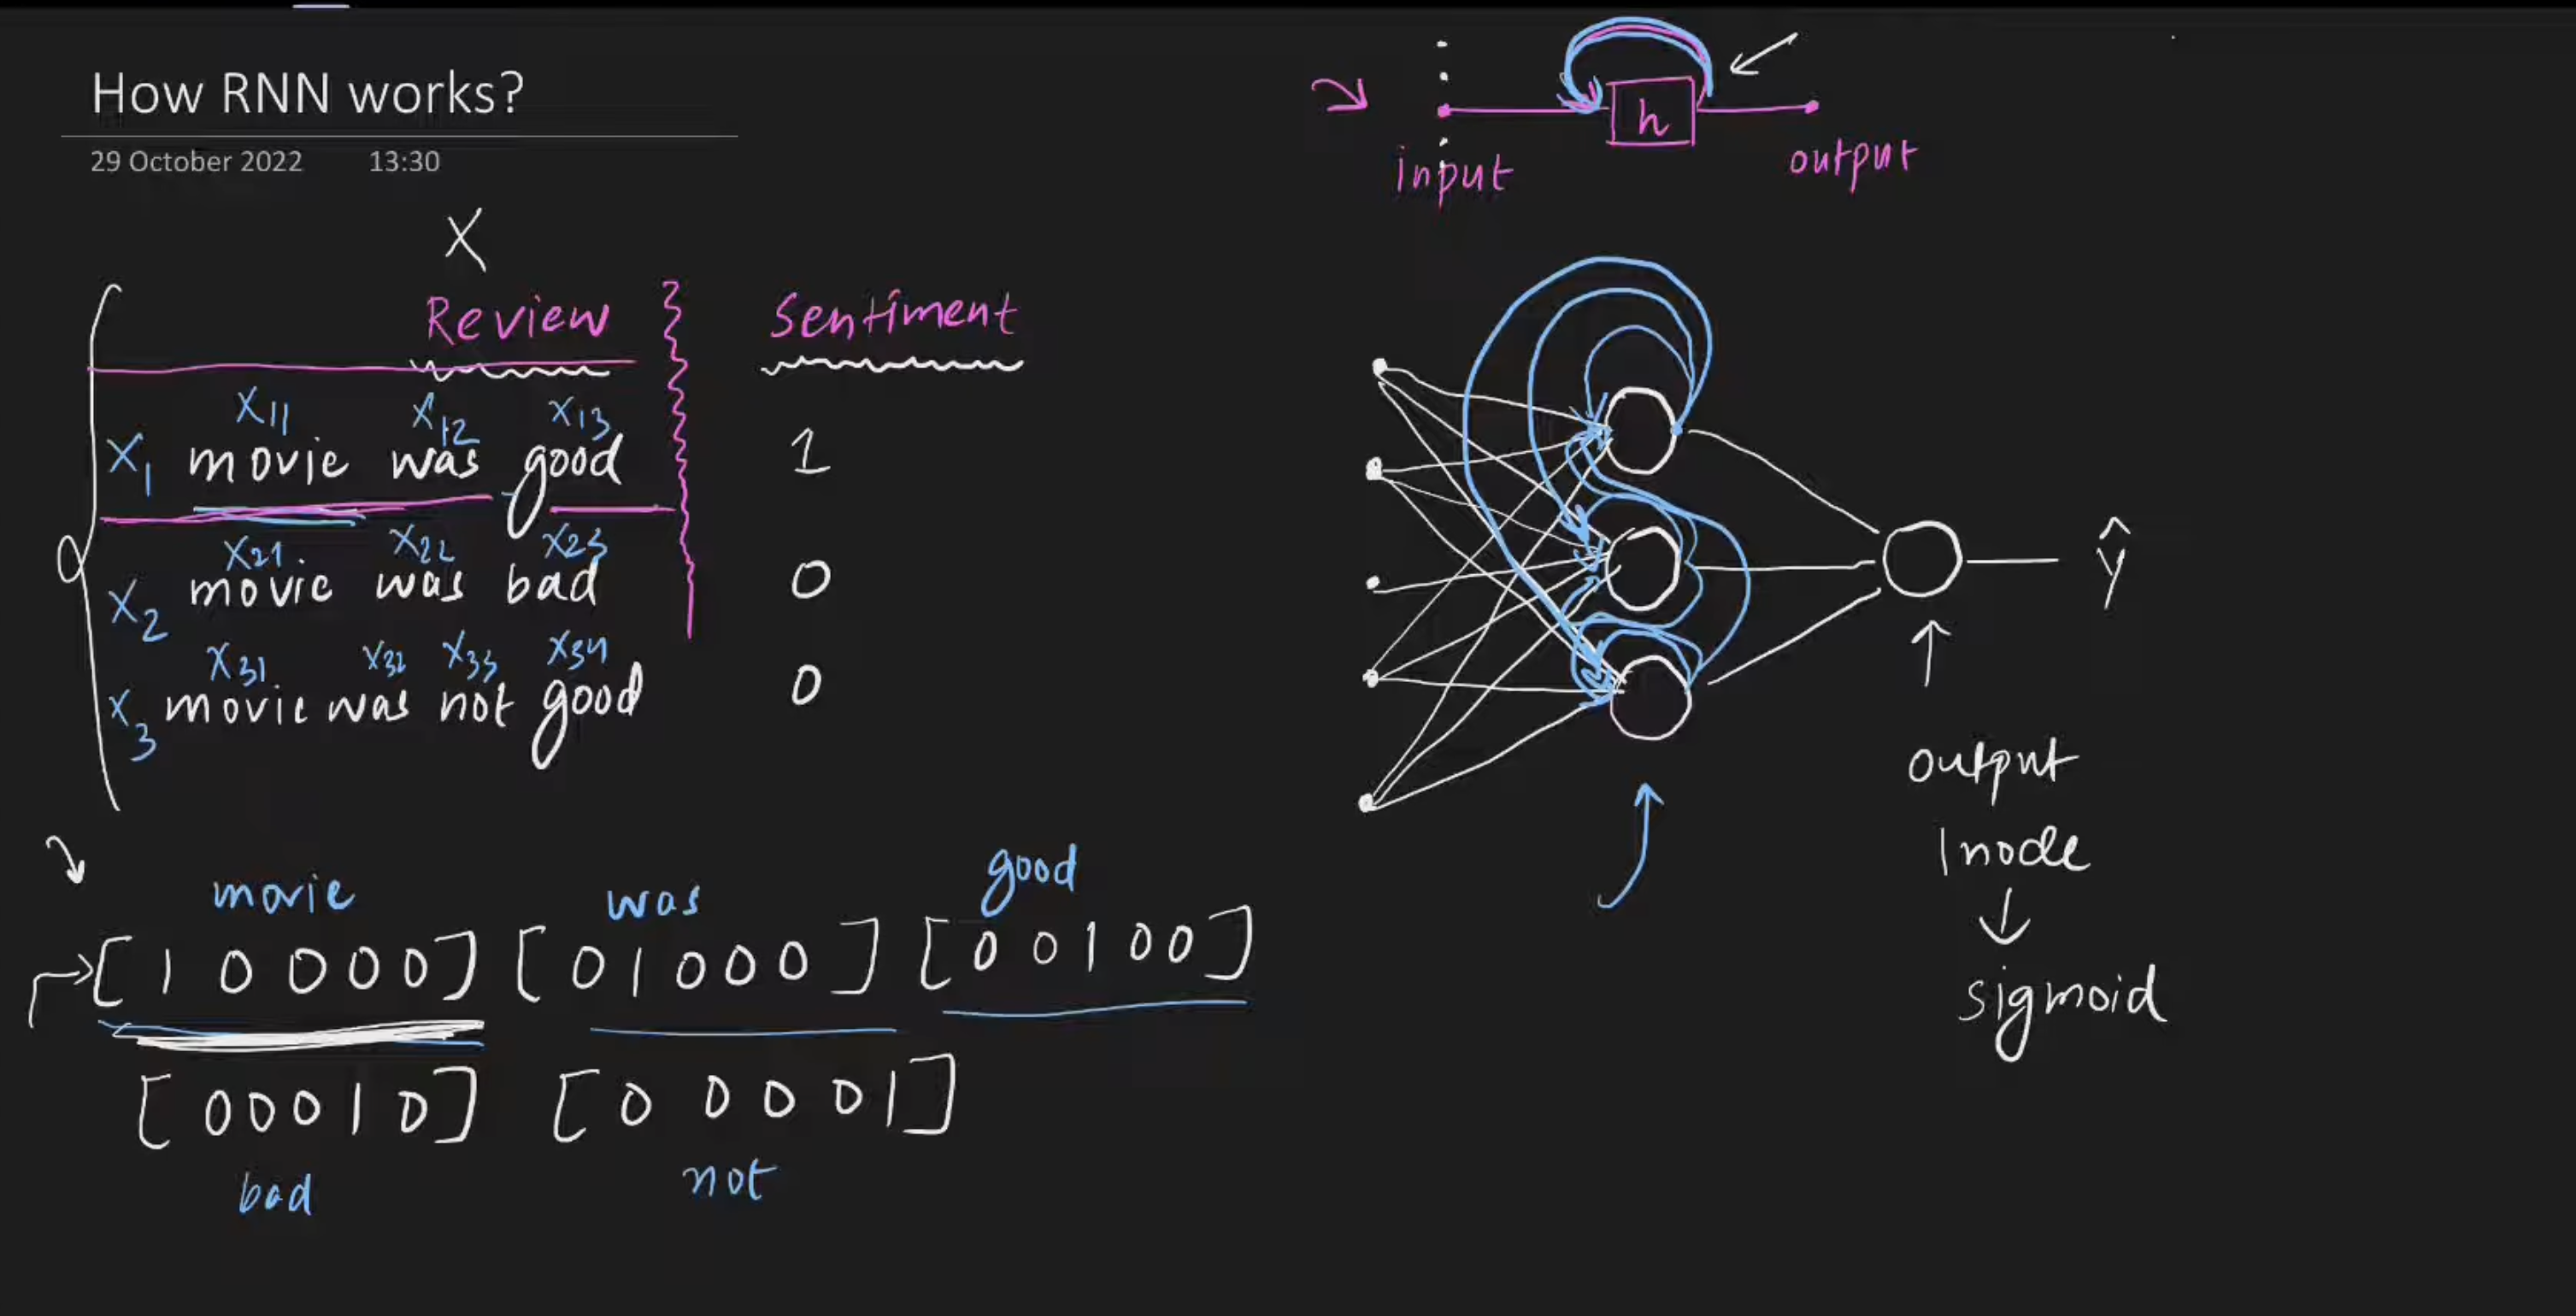
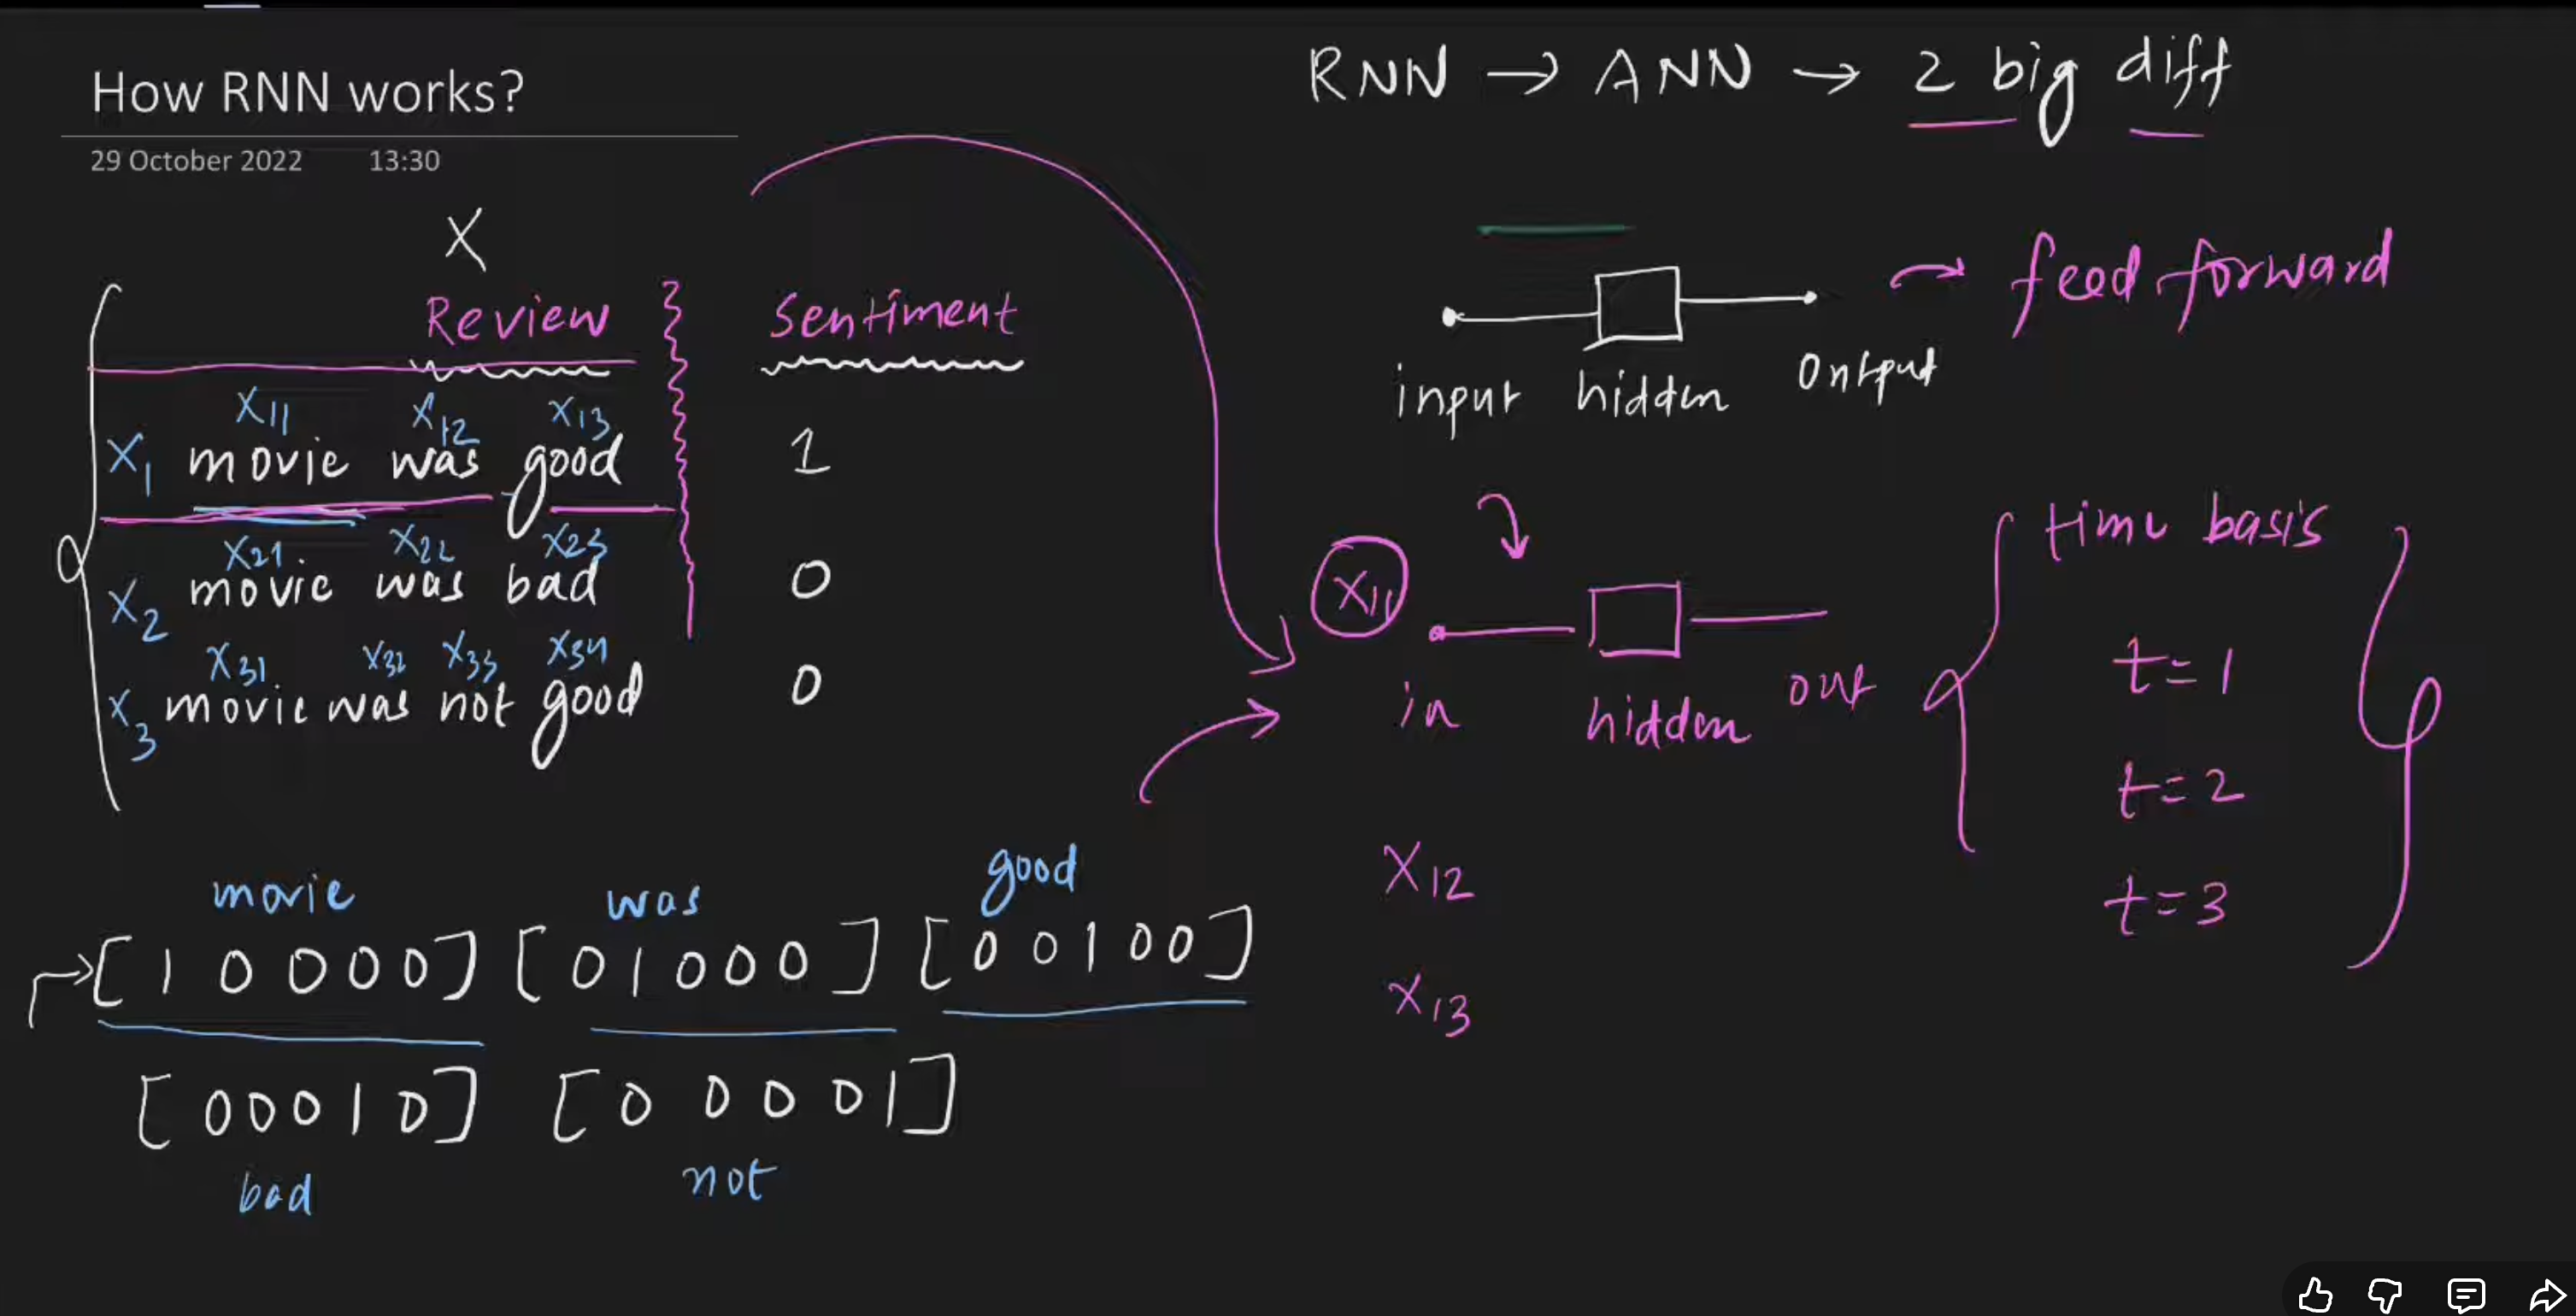

#### Basic Building Blocks
An RNN architecture consists of:

1. **Input Layer** – receives the input vector at each time step.
2. **Hidden Layer(s)** – processes the input and the previous hidden state. This is where the "memory" lives.
3. **Output Layer** – produces the prediction at each time step (or only at the final step, depending on the task).

#### The Recurrent Connection – The Key Difference
In a regular feedforward network, information flows in one direction:  
**Input → Hidden → Output**

In an RNN, the hidden layer has an additional connection: it sends its output **back to itself**. This creates a loop.

> **Analogy:** Imagine you are reading a book. At each word, your understanding depends not just on the current word, but also on what you have read so far. Your brain (the hidden layer) takes the current word (input) and your memory of previous words (previous hidden state) to form a new understanding (new hidden state).

#### Architecture Diagram (Based on Transcript)
The transcript describes the following:

- **Input layer** has neurons equal to the number of **input features** (e.g., 5 for vocabulary size).
- **Hidden layer** has neurons (e.g., 3 neurons).
- **Output layer** has neurons equal to the number of classes (e.g., 2 for binary sentiment: positive/negative).
- The hidden layer is **fully connected** to both the input and the output.
- The hidden layer also has **recurrent connections** – its output at time `t-1` is fed back as input at time `t`.

#### Unfolding Through Time
The transcript introduces the concept of **"unfolding through time"** – this is a way to visualize the RNN loop as a chain of identical networks, one for each time step.

- At `t=1`, only `X₁₁` is the input (no previous hidden state, so we use a zero vector).
- At `t=2`, the inputs are `X₁₂` AND the hidden state from `t=1`.
- At `t=3`, the inputs are `X₁₃` AND the hidden state from `t=2`.
- This continues for all time steps.

#### Weight Sharing
A very important concept: **the same weights are used at every time step**.

- The weight matrix `W₁` is used for input-to-hidden connections at ALL time steps.
- The weight matrix `W₂` is used for hidden-to-hidden (recurrent) connections at ALL time steps.
- The weight matrix `W₃` is used for hidden-to-output connections at ALL time steps.

This dramatically reduces the number of parameters compared to having separate weights for each time step.

#### Parameter Calculation Example (from transcript)
The transcript gives a concrete example:
- Input features = 5 (vocabulary size)
- Hidden neurons = 3
- Output neurons = 2 (binary classification)

**Parameter count:**
- Input to hidden: 5 × 3 = 15 weights
- Hidden biases: 3 biases
- Hidden to hidden (recurrent): 3 × 3 = 9 weights
- Hidden to output: 3 × 2 = 6 weights
- Output biases: 2 biases

**Total = 15 + 3 + 9 + 6 + 2 = 35 parameters** (the transcript mentions 31, likely with a slight variation in architecture – the concept remains the same).

#### Activation Functions
- Hidden layer activation: usually **tanh** (hyperbolic tangent) by default in many RNN implementations.
- Output layer activation: depends on the task:
  - **Binary classification** (positive/negative): Sigmoid
  - **Multi-class classification**: Softmax
  - **Regression**: Linear (no activation)

---

### 3. Key Points

- RNN architecture = **input layer + hidden layer (with feedback loop) + output layer**.
- The **hidden layer** is the memory – it receives both the current input and the previous hidden state.
- **Weight sharing** – same weights are reused across all time steps, reducing parameters.
- **Unfolding through time** – visualizing the loop as a chain of networks, one per time step.
- At `t=1`, the previous hidden state is a **zero vector** (no prior memory).
- Activation functions: `tanh` for hidden layer, `sigmoid`/`softmax` for output (depending on task).
- Total parameters can be calculated by multiplying layer sizes and adding biases.

---

### 4. Syntax/Structure (Conceptual – Not Code)

The transcript doesn't provide actual code, but describes the structure conceptually:

```
Input: (time_steps, input_features)

At each time step t:
  - Input = current word vector (x_t)
  - Previous hidden state = h_{t-1} (zero at t=1)
  - h_t = activation_function( W₁ · x_t + W₂ · h_{t-1} + bias_h )
  - output_t = activation_function( W₃ · h_t + bias_o )
```

Where:
- `W₁` = input-to-hidden weights
- `W₂` = hidden-to-hidden (recurrent) weights
- `W₃` = hidden-to-output weights

---

### 5. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Forgetting the recurrent connection | Without it, it's just a feedforward network | Always include the feedback loop in your diagrams and calculations |
| Using different weights for each time step | Weight sharing is fundamental to RNNs | Remember: same W₁, W₂, W₃ for all time steps |
| Ignoring the previous hidden state at t=1 | The first step has no previous output | Use a zero vector as `h₀` |
| Confusing input features with time steps | Time steps = sequence length; features = vector size per word | Data shape = (time steps, features) |
| Using wrong activation function for output | Sigmoid is for binary, softmax for multi-class | Match activation to your task |

---

### 6. Revision Notes

- RNN architecture = **input → hidden (with feedback) → output**.
- Hidden layer receives: **(current input) + (previous hidden state)**.
- **Same weights** used for all time steps (weight sharing).
- **Unfolding through time** = drawing the loop as a chain.
- `h₀ = zero vector` (initial memory).
- Parameters = (input_size × hidden_size) + (hidden_size × hidden_size) + (hidden_size × output_size) + all biases.

---

**That concludes Topic 2.**  


## Topic 3: Forward Propagation in RNN – Step-by-Step Process

### 1. Introduction
**What it is:**  
**Forward propagation** is the process of passing input data through the network to generate an output (prediction). In RNNs, this happens **sequentially** – time step by time step – with information flowing from the input, through the hidden layer (with its memory), to the output.

**Why important:**  
Forward propagation is how the RNN actually makes predictions. Understanding it is essential before you can understand how the network learns (backpropagation). It also shows you exactly how the "memory" works in practice.

**Real-life use:**  
Every time an RNN makes a prediction – whether it's classifying a movie review as positive/negative, translating a sentence, or predicting the next word – forward propagation is what computes that prediction.

---

### 2. Detailed Explanation

#### The Core Operation – Step by Step

The transcript explains forward propagation with a **sentiment analysis example**: we have a movie review consisting of 3 words: "this", "movie", "actor". Each word is a vector of 5 numbers (vocabulary size = 5).

**Notation (from transcript):**
- `X₁₁` = first word of first review
- `X₁₂` = second word of first review  
- `X₁₃` = third word of first review

**Step-by-step forward propagation:**

---

**Step 1: Time Step t = 1**

- **Input:** The first word `X₁₁` (vector of size 5) is fed into the network.
- **Previous hidden state:** Since this is the first step, there is no previous output. So we use a **zero vector** `h₀ = [0, 0, 0]` (size = hidden layer size, which is 3 neurons).
- **Hidden layer calculation:**
  
  ```
  h₁ = tanh( W₁ · X₁₁ + W₂ · h₀ + bias_h )
  ```
  
  - `W₁` = weight matrix for input-to-hidden (size: 5×3)
  - `W₂` = weight matrix for hidden-to-hidden (size: 3×3)
  - `h₀` = zero vector (size: 3)
  - `bias_h` = bias for hidden layer (size: 3)
  
- **Output calculation** (if needed at this step):
  
  ```
  o₁ = sigmoid( W₃ · h₁ + bias_o )
  ```
  
  - `W₃` = weight matrix for hidden-to-output (size: 3×2)
  - `bias_o` = bias for output layer (size: 2)

- **Result:** We get a hidden state `h₁` and an output `o₁`. The hidden state `h₁` is stored and will be used in the next time step.

---

**Step 2: Time Step t = 2**

- **Input:** The second word `X₁₂` (vector of size 5) is fed into the network.
- **Previous hidden state:** This time, we have `h₁` from the previous step.
- **Hidden layer calculation:**
  
  ```
  h₂ = tanh( W₁ · X₁₂ + W₂ · h₁ + bias_h )
  ```
  
  - Notice: `W₁` and `W₂` are the **same weights** as in step 1 (weight sharing).
  - `h₁` comes from the previous time step – this is the **memory** in action!

- **Output calculation:**
  
  ```
  o₂ = sigmoid( W₃ · h₂ + bias_o )
  ```

- **Result:** We get `h₂` and `o₂`. `h₂` is passed to the next step.

---

**Step 3: Time Step t = 3 (Final Step)**

- **Input:** The third word `X₁₃` (vector of size 5) is fed into the network.
- **Previous hidden state:** `h₂` from step 2.
- **Hidden layer calculation:**
  
  ```
  h₃ = tanh( W₁ · X₁₃ + W₂ · h₂ + bias_h )
  ```

- **Final output calculation:**
  
  ```
  o₃ = sigmoid( W₃ · h₃ + bias_o )
  ```

- **Result:** `o₃` is the **final prediction** for the entire review. If `o₃` is close to 1 → positive sentiment; if close to 0 → negative sentiment.

> **Important note from transcript:** In this example, we only care about the **final output** (after the last word). The outputs at intermediate steps (`o₁`, `o₂`) are not used for the final classification, but they still get computed as part of the forward pass.

---

#### Simplified Representation (from transcript)

The transcript gives a simplified box representation:

> "You can imagine an RNN like a box in which two inputs meet:
> 1. The current input (`X_t`)
> 2. The previous output (`h_{t-1}`)
>
> You do a dot product, add them, pass through an activation function, and get the current output (`h_t`)."

**Mathematical summary:**
```
h_t = tanh( W₁ · X_t + W₂ · h_{t-1} + bias_h )
o_t = sigmoid( W₃ · h_t + bias_o )
```

#### What Gets Passed Forward
- The **hidden state** `h_t` is passed to the next time step.
- The **output** `o_t` can be used for prediction (if final step) or just computed and discarded (if intermediate step).

#### What Happens to Sequential Information?
The transcript explains:

> "When you are finally calculating your output in the last step, there is a component of the previous output. A simple RNN can process a sequence of 10 time steps – meaning it can store information from the last 10 time steps."

In other words, `h₃` contains information from `h₂`, which contains information from `h₁`, which contains information from `X₁₁`. So the final hidden state `h₃` has **accumulated information from all three words**.

---

### 3. Key Points

- **Forward propagation in RNN = sequential processing** – one time step at a time.
- At each time step `t`, the network receives:
  - Current input `X_t`
  - Previous hidden state `h_{t-1}` (memory)
- The hidden state is updated as:
  
  `h_t = tanh( W₁ · X_t + W₂ · h_{t-1} + bias_h )`
  
- The output is computed as:
  
  `o_t = sigmoid( W₃ · h_t + bias_o )`
  
- **Weight sharing:** Same `W₁`, `W₂`, `W₃` used at all time steps.
- At `t=1`, `h₀` is a **zero vector** (no prior memory).
- The **final output** (at the last time step) is used for prediction.
- The hidden state accumulates information from all previous time steps.

---

### 4. Code Examples

> **Note:** The transcript does not contain actual code. 
---

### 5. Output 


---

### 6. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Forgetting to pass `h_{t-1}` forward | The hidden state IS the memory – without it, no sequence information | Always store and pass `h_t` to the next step |
| Using `h₀` as random instead of zero | At t=1, there is no prior memory – it should be zero | Initialize `h₀ = [0, 0, ..., 0]` |
| Applying different weights at each step | Weight sharing is a core feature | Use the exact same weight matrices for all steps |
| Thinking all outputs are used for prediction | In classification, only the final output matters | Distinguish between intermediate and final outputs |
| Confusing dot product order | Matrix dimensions must match | Check: `W₁` (hidden × features) · `X_t` (features × 1) → works |

---

### 7. Revision Notes

- **Forward propagation** = sequential processing from t=1 to t=T.
- **Formula:**
  - `h_t = tanh( W₁ · X_t + W₂ · h_{t-1} + bias_h )`
  - `o_t = sigmoid( W₃ · h_t + bias_o )`
- **h₀** = zero vector (no memory initially).
- **Same weights** used for all time steps.
- Each `h_t` contains information from **all previous time steps**.
- Final `o_T` is the prediction (for classification tasks).

---

**That concludes Topic 3.**  


## Topic 4: Weight Sharing, Parameters, and Unfolding Through Time

### 1. Introduction
**What it is:**  
**Weight sharing** means that the same set of weights (parameters) is reused at every time step in the RNN. **Unfolding through time** is a visual technique that "unrolls" the recurrent loop into a chain of identical layers, making it easier to understand and implement.

**Why important:**  
Weight sharing is what makes RNNs efficient and powerful. It drastically reduces the number of parameters compared to having separate weights for each time step. Unfolding helps us visualize and mathematically describe the flow of information across time – and it is essential for understanding backpropagation (which comes in later videos).

**Real-life use:**  
These concepts are foundational. When you implement an RNN in code (e.g., using TensorFlow or PyTorch), you don't manually define weights for each time step – you define one set of weights that gets shared, precisely because of this principle.

---

### 2. Detailed Explanation

#### What is Weight Sharing?

In a regular feedforward neural network, each connection between two layers has its own weight. In an RNN, however:

- The **input-to-hidden** weights (`W₁`) are the **same at every time step**.
- The **hidden-to-hidden** (recurrent) weights (`W₂`) are the **same at every time step**.
- The **hidden-to-output** weights (`W₃`) are the **same at every time step**.

**Why does this make sense?**
The network applies the same transformation to each word in the sequence. The word "movie" should be processed the same way whether it appears at position 2, position 5, or position 10. The only difference is the **context** (the previous hidden state) that comes along with it.

> **Analogy:** Think of a chef following a recipe. The recipe steps (weights) are the same regardless of which ingredient (word) is being processed. But the chef's memory of what they've already cooked (hidden state) changes with each step.

#### The Benefit of Weight Sharing

**Without weight sharing:**
- If you had 10 time steps, you would need 10 separate sets of `W₁`, `W₂`, `W₃` → huge number of parameters.
- The model size would grow with sequence length, making it impractical.

**With weight sharing (RNN):**
- You use the exact same `W₁`, `W₂`, `W₃` for all time steps.
- The number of parameters is **fixed** and does **not depend** on sequence length.
- The model can handle sequences of any length with the same set of parameters.

#### Parameter Calculation Example (from transcript)

The transcript gives a concrete example:

- **Input features (vocabulary size):** 5
- **Hidden layer neurons:** 3
- **Output neurons:** 2 (binary classification)

| Connection | Weight Matrix Size | Number of Weights |
|------------|-------------------|-------------------|
| Input to Hidden | 5 × 3 | 15 |
| Hidden biases | 3 | 3 |
| Hidden to Hidden (recurrent) | 3 × 3 | 9 |
| Hidden to Output | 3 × 2 | 6 |
| Output biases | 2 | 2 |
| **Total** | | **35** |

> The transcript mentions **31 parameters** – the slight difference is likely due to a variation in architecture (e.g., not including certain biases in their count). The important takeaway is **how to calculate** these values.

#### Unfolding Through Time

**What is unfolding?**
The transcript introduces this as: *"A concept which is called unfolding through time."*

Since the RNN has a loop (hidden layer feeds back into itself), we can "unroll" this loop to visualize it as a chain of networks, one for each time step.

**Visualization:**

**Before unfolding (the loop):**
```
         output
           ↑
    [Hidden Layer] ← (feedback loop from previous step)
           ↑
         input
```

**After unfolding (the chain):**
```
t=1:         t=2:         t=3:
X₁₁ → [H] → h₁ → [H] → h₂ → [H] → h₃ → o₃
           ↑         ↑
         (h₀=0)   (h₁)
```

Each box `[H]` represents the **same hidden layer** with the **same weights** (`W₁`, `W₂`, `W₃`). The only difference is:
- At `t=1`, input = `X₁₁` + `h₀` (zero)
- At `t=2`, input = `X₁₂` + `h₁`
- At `t=3`, input = `X₁₃` + `h₂`

**Why we unfold:**
- It makes the architecture look like a deep feedforward network with shared weights.
- It allows us to apply backpropagation across time (Backpropagation Through Time – BPTT), which will be covered in future videos.
- It clarifies how information flows from the beginning to the end of the sequence.

#### How Memory Works (Accumulation over Time)

The transcript explains:

> *"A simple RNN can process a sequence of 10 time steps – meaning it can store information from the last 10 time steps."*

What does this mean in practice?

- `h₁` = f(`X₁₁`) → contains info from word 1
- `h₂` = f(`X₁₂`, `h₁`) → contains info from words 2 AND 1
- `h₃` = f(`X₁₃`, `h₂`) → contains info from words 3, 2, AND 1
- … and so on.

So the final hidden state `h_T` contains **accumulated information from the entire sequence**. This is how RNNs "remember" the context.

---

### 3. Key Points

- **Weight sharing:** The same `W₁`, `W₂`, `W₃` are reused at every time step.
- **Benefits of weight sharing:**
  - Reduces number of parameters dramatically.
  - Allows handling of **variable-length sequences**.
  - Prevents overfitting (fewer parameters).
- **Parameters are fixed** and do not depend on sequence length.
- **Unfolding through time:** A visualization technique that unrolls the recurrent loop into a chain of identical layers.
- The unfolded structure clearly shows how `h_{t-1}` feeds into step `t`.
- **Memory accumulation:** Each hidden state `h_t` contains information from all previous time steps.
- The model can process sequences of any length – the memory persists as long as the sequence continues.

---

### 4. Structure/Mathematical Representation (Based on Transcript)

**Weight matrices and their roles:**

| Symbol | Connection | Size | Role |
|--------|------------|------|------|
| `W₁` | Input → Hidden | (hidden_size × input_features) | Transforms current input |
| `W₂` | Hidden → Hidden (recurrent) | (hidden_size × hidden_size) | Transforms previous hidden state (memory) |
| `W₃` | Hidden → Output | (output_size × hidden_size) | Transforms hidden state to output |

**The unfolded equations for T=3:**
```
h₁ = tanh( W₁·X₁₁ + W₂·h₀ + bias_h )
h₂ = tanh( W₁·X₁₂ + W₂·h₁ + bias_h )
h₃ = tanh( W₁·X₁₃ + W₂·h₂ + bias_h )
o₃ = sigmoid( W₃·h₃ + bias_o )
```

Notice:
- Same `W₁`, `W₂`, `W₃` in all equations.
- `h₀` is zero vector.
- `h₁` appears in the equation for `h₂`, `h₂` appears in the equation for `h₃` – this is the **recurrent connection** in unfolded form.

---

### 5. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Thinking different time steps use different weights | RNNs use **shared weights** – this is a core principle | Remember: one set of `W₁`, `W₂`, `W₃` for all steps |
| Assuming parameters grow with sequence length | With weight sharing, parameters are fixed | The number of parameters depends only on layer sizes, not on `T` |
| Confusing unfolding with actual separate layers | Unfolding is just a **visualization** – in practice, it's one layer with a loop | Think of unfolding as a "drawing aid" for understanding |
| Forgetting that `h₀` is a zero vector | Without this, the first step would have no baseline | Always initialize hidden state to zeros at the start |
| Not understanding how memory accumulates | Each `h_t` depends on ALL previous `h`'s | Trace it back: `h₃` depends on `h₂`, `h₂` depends on `h₁`, etc. |

---

### 6. Revision Notes

- **Weight sharing = same weights at all time steps** → efficient, scalable.
- **Parameters = fixed** (independent of sequence length).
- Calculation example: (5 × 3) + 3 + (3 × 3) + (3 × 2) + 2 = 35 parameters.
- **Unfolding through time** = unrolling the loop into a chain of identical layers.
- Unfolded equations clearly show:
  - Current input (`X_t`)
  - Previous hidden state (`h_{t-1}`)
  - Current hidden state (`h_t`)
- Each `h_t` carries **accumulated memory** from the start of the sequence.
- Initial hidden state `h₀ = [0, 0, ..., 0]`.

---

**That concludes Topic 4.**  


## Topic 5: Complete Forward Propagation Walkthrough with Simplified Representation

### 1. Introduction
**What it is:**  
This topic provides a **complete, consolidated walkthrough** of forward propagation in an RNN, using the simplified "box" representation introduced in the transcript. It ties together everything we've covered – architecture, weight sharing, unfolding, and the step-by-step calculations – into one clear, cohesive picture.

**Why important:**  
This is the **big-picture understanding** you need before moving on to more advanced topics like backpropagation (which the transcript mentions will come in future videos). Once you can visualize the entire forward pass as a single coherent process, the rest becomes much easier.

**Real-life use:**  
When you implement an RNN for any real-world task, this is exactly what happens under the hood – each time step processes input plus previous memory, and the final output gives your prediction.

---

### 2. Detailed Explanation

#### The Simplified "Box" Representation

The transcript gives a beautiful simplification:

> *"You can imagine an RNN like a box in which two inputs meet:*
> 1. *The current input (`X_t`) – representing the present time step.*
> 2. *The previous output (`h_{t-1}`) – coming from the recurrent connection.*
>
> *You do a dot product, add them, pass through an activation function, and get the current output (`h_t`)."*

**What this box does at each time step:**

```
          ┌─────────────────────┐
X_t ──────│                     │──────► h_t
          │   RNN CELL (box)    │
h_{t-1} ──│   (same layer)      │──────► o_t (optional)
          │                     │
          └─────────────────────┘
```

Inside the box, the operation is:

```
1. Combine:   W₁ · X_t  +  W₂ · h_{t-1}  +  bias_h
2. Activate:  h_t = tanh( ... )
3. Output:    o_t = sigmoid( W₃ · h_t + bias_o )
```

#### Complete Walkthrough: Sentiment Analysis Example

Let's walk through the **entire forward pass** for one review: **"this movie actor"**

**Setup:**
- Vocabulary size = 5 → `[this, movie, actor, is, good]`
- One-hot vectors:
  - `this`  → [1, 0, 0, 0, 0]
  - `movie` → [0, 1, 0, 0, 0]
  - `actor` → [0, 0, 1, 0, 0]
- Hidden size = 3 neurons
- Output size = 2 (positive/negative)
- Activation: `tanh` for hidden, `sigmoid` for output

**Weights (randomly initialized – these are what the network learns):**
- `W₁` (5×3): input-to-hidden
- `W₂` (3×3): hidden-to-hidden (recurrent)
- `W₃` (3×2): hidden-to-output
- `bias_h` (3): hidden bias
- `bias_o` (2): output bias

**Initial hidden state:** `h₀ = [0, 0, 0]` (no memory yet)

---

#### Time Step 1 (t=1) – First word: "this"

```
Inputs to the RNN box:
  - Current input: X₁ = [1, 0, 0, 0, 0]  ("this")
  - Previous hidden state: h₀ = [0, 0, 0]

Inside the box:
  1. Dot product: W₁ · X₁   → gives a 3-element vector
  2. Dot product: W₂ · h₀   → gives a 3-element vector (all zeros because h₀=0)
  3. Add: (W₁·X₁) + (W₂·h₀) + bias_h
  4. Apply tanh: h₁ = tanh( ... )

Output from the box:
  - New hidden state: h₁ (stored for next step)
  - Optional output: o₁ = sigmoid( W₃ · h₁ + bias_o )  [discarded]

What has happened?
  - h₁ contains information about "this".
  - Since h₀ was zero, h₁ only reflects the current word.
```

---

#### Time Step 2 (t=2) – Second word: "movie"

```
Inputs to the RNN box:
  - Current input: X₂ = [0, 1, 0, 0, 0]  ("movie")
  - Previous hidden state: h₁ (from step 1)

Inside the box:
  1. Dot product: W₁ · X₂   → 3-element vector (current word)
  2. Dot product: W₂ · h₁   → 3-element vector (memory from previous step)
  3. Add: (W₁·X₂) + (W₂·h₁) + bias_h
  4. Apply tanh: h₂ = tanh( ... )

Output from the box:
  - New hidden state: h₂ (stored for next step)
  - Optional output: o₂ = sigmoid( W₃ · h₂ + bias_o )  [discarded]

What has happened?
  - h₂ contains information about "movie" AND "this" (because h₁ carried "this").
  - This is the memory at work!
```

---

#### Time Step 3 (t=3) – Third word: "actor" (FINAL STEP)

```
Inputs to the RNN box:
  - Current input: X₃ = [0, 0, 1, 0, 0]  ("actor")
  - Previous hidden state: h₂ (from step 2)

Inside the box:
  1. Dot product: W₁ · X₃   → 3-element vector (current word)
  2. Dot product: W₂ · h₂   → 3-element vector (memory from previous steps)
  3. Add: (W₁·X₃) + (W₂·h₂) + bias_h
  4. Apply tanh: h₃ = tanh( ... )

Final output:
  - New hidden state: h₃ (contains info from all 3 words)
  - FINAL PREDICTION: o₃ = sigmoid( W₃ · h₃ + bias_o )

What has happened?
  - o₃ is the final sentiment prediction!
  - If o₃ ≈ [1, 0] → positive review
  - If o₃ ≈ [0, 1] → negative review
  - h₃ has accumulated all three words: "this", "movie", "actor"
```

#### Summary of the Entire Forward Pass

| Step | Input Word | Previous h | New h | Output Used? |
|------|------------|------------|-------|--------------|
| t=1 | this (X₁)  | h₀ = [0,0,0] | h₁ | o₁ (discarded) |
| t=2 | movie (X₂) | h₁          | h₂ | o₂ (discarded) |
| t=3 | actor (X₃) | h₂          | h₃ | o₃ → final prediction |

**Important observation:** The transcript emphasizes:

> *"At t=1, you have only one input (`X₁₁`). At all other steps, you have TWO inputs: the current word AND the output from the previous step."*

---

### 3. Key Points

- The RNN **"box"** takes **two inputs** at each step (except t=1):
  - Current input `X_t`
  - Previous hidden state `h_{t-1}`
- **Inside the box:**
  - Multiply current input by `W₁`
  - Multiply previous hidden state by `W₂`
  - Add both products plus bias
  - Apply `tanh` to get new hidden state `h_t`
- **Output (optional):** Multiply `h_t` by `W₃`, add bias, apply `sigmoid` → `o_t`
- For **classification tasks**, only the **final output** `o_T` is used for prediction.
- The hidden state `h_t` always carries **accumulated information** from all previous time steps.
- The same "box" (same weights) is reused at every time step.
- At `t=1`, `h₀` is a **zero vector** – no previous memory.

---

### 4. Structure/Mathematical Summary

**General forward propagation for sequence of length T:**

```
h₀ = [0, 0, ..., 0]                        # initial memory

for t = 1 to T:
    h_t = tanh( W₁ · X_t  +  W₂ · h_{t-1}  +  bias_h )
    o_t = sigmoid( W₃ · h_t + bias_o )

prediction = o_T                             # final output
```

**Key:**
- Same `W₁`, `W₂`, `W₃` for all `t` (weight sharing)
- `h_t` depends on `X_t` AND `h_{t-1}` (memory)
- `h_{t-1}` depends on `X_{t-1}` AND `h_{t-2}` … so `h_t` has information from the entire sequence

---

### 5. Output (Based on Transcript)

For the example review "this movie actor":

```
Input sequence: X₁ (this), X₂ (movie), X₃ (actor)

Forward pass:
  t=1: h₁ = tanh( W₁·X₁ + W₂·0 + bias_h )  → stores "this"
  t=2: h₂ = tanh( W₁·X₂ + W₂·h₁ + bias_h ) → stores "this" + "movie"
  t=3: h₃ = tanh( W₁·X₃ + W₂·h₂ + bias_h ) → stores "this" + "movie" + "actor"

Final prediction:
  o₃ = sigmoid( W₃·h₃ + bias_o )

If o₃ = [0.87, 0.13] → positive sentiment (first neuron high)
If o₃ = [0.21, 0.79] → negative sentiment (second neuron high)
```

---

### 6. Common Mistakes

| Mistake | Why It's Wrong | How to Avoid |
|---------|----------------|---------------|
| Thinking the previous hidden state is optional | It's **essential** – without it, you lose all memory | Always include `h_{t-1}` in the calculation |
| Using the same `h` for all steps | The hidden state updates at every time step | Each `t` produces a **new** `h_t` |
| Using intermediate outputs for classification | In many tasks (like sentiment analysis), only the **final** output matters | Check your task – if it's sequence classification, use `o_T` only |
| Forgetting that `tanh` is the hidden activation | The transcript specifies `tanh` for hidden | Use `tanh` (or `ReLU`) for hidden, `sigmoid`/`softmax` for output |
| Not carrying `h_t` forward to the next step | This is how memory works | Always store `h_t` and use it as `h_{t-1}` in the next iteration |

---

### 7. Interview/Exam Questions

**Q1:** In an RNN, what are the two inputs to the hidden layer at time step `t` (for `t > 1`)?

**A1:** The current input `X_t` and the previous hidden state `h_{t-1}`.

---

**Q2:** Why is `h₀` set to a zero vector?

**A2:** At the first time step, there is no previous information/memory. A zero vector represents this absence of prior context.

---

**Q3:** What is weight sharing in RNNs and why is it important?

**A3:** Weight sharing means the same weights (`W₁`, `W₂`, `W₃`) are used at every time step. It reduces the number of parameters, allows the model to handle sequences of variable length, and ensures the same transformation is applied to each input regardless of position.

---

**Q4:** In the forward propagation equation `h_t = tanh( W₁·X_t + W₂·h_{t-1} + bias_h )`, what does each term represent?

**A4:**
- `W₁·X_t` = transformation of the current input
- `W₂·h_{t-1}` = transformation of the previous memory/hidden state
- `bias_h` = bias term for the hidden layer
- `tanh` = activation function introducing non-linearity

---

**Q5:** If you have an RNN with 10 input features, 4 hidden neurons, and 3 output classes, how many total parameters does it have?

**A5:**
- Input to hidden: 10 × 4 = 40
- Hidden bias: 4
- Hidden to hidden: 4 × 4 = 16
- Hidden to output: 4 × 3 = 12
- Output bias: 3
- **Total = 40 + 4 + 16 + 12 + 3 = 75 parameters**

---

### 8. Revision Notes

- RNN forward propagation = **sequential processing** of inputs with **memory**.
- **Two inputs** to the hidden layer at each step: `X_t` + `h_{t-1}`.
- **Formula:**
  - `h_t = tanh( W₁·X_t + W₂·h_{t-1} + bias_h )`
  - `o_t = sigmoid( W₃·h_t + bias_o )`
- **Initial state:** `h₀ = zero vector`.
- **Weight sharing:** same `W₁`, `W₂`, `W₃` for all time steps.
- **Final output** `o_T` = prediction (for classification).
- `h_t` accumulates information from **all previous time steps**.
- **Unfolding through time** = visualizing the loop as a chain.
- This is exactly how RNNs process sequences and make predictions.

---

**That concludes Topic 5 – the final topic in this series.**

---

🎉 **All topics from the transcript have been covered!**

**Summary of all topics:**
1. Introduction to RNNs – Why We Need Them
2. RNN Architecture – Structure and Components
3. Forward Propagation in RNN – Step-by-Step Process
4. Weight Sharing, Parameters, and Unfolding Through Time
5. Complete Forward Propagation Walkthrough with Simplified Representation

